Step L2 \
Notebook to run mean_dist, then join kuhn greenness (HLakes) to liu greenness (GLAKES), then to GLOBATHY \
This is a difficult to join, because they are not one-to-one relationships between HL and GL.
Notes:
* Calculating mean dist takes 36 hrs
* Joins from GLAKES to HL are done using "overlaps": then duplicate GL indexes (one-many) are aggregated (CAUTION with vars like max depth, for which custom aggregation is not performed). Duplicate HL (many-one) are kept, meaning some GLAKES will have the same greenness values, but this is because they were pieces of the same HL lake.

Prerequisite: fix HL geoms,.

TODO:
* Custom aggregations or area checks between GL and HL

In [ ]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
import os
import numpy as np
from shapely.geometry import box

from land_cover.load import plot_dir, loadKuhnGreenness, loadGreenness, loadLiu, loadGlobathy, GLAKES_filtered_fix_aqveg_dist_pth, greennessx2_albers_pth, greennessx2_albers_pth, old_GLAKES_filtered_fix_aqveg_dist_pth
from land_cover.distance import calcMeanBoundDist
from land_cover.joins import merge_left_one_one
from land_cover.plotting import reg_hexplot


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
# t
print(GLAKES_filtered_fix_aqveg_dist_pth)

/Volumes/metis/Datasets/Liu_aq_veg/figshare/v4/25012091/edk_out/GLAKES_filtered_fix_aqveg_dist.gpkg


In [62]:
gdf_liu = loadLiu()

In [63]:
# TEMP: crop down gdf
# gdf_liu = gdf_liu[100000:100100].reset_index(drop=True)

In [64]:
gdf_liu

,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,LEV_p2,LEV_p3,LEV_p13ain,LEV_p13rin,LEV_p23ain,LEV_p23rin,LEV_p13occ_ain,LEV_p23occ_ain,LEV_p13in,geometry
0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,0,...,0.007922,0.007740,-0.601649,-0.000771,-0.185964,-0.000181,0.000816,0.000750,-0.000744,"MULTIPOLYGON (((-92.00626 46.68239, -92.00653 ..."
1,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,0,...,0.002080,0.003208,0.645770,0.002105,0.342653,0.001128,0.000087,0.000064,0.002141,"MULTIPOLYGON (((-119.5765 66.99075, -119.5765 ..."
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-96.8945 55.40917, -96.89435 5..."
3,11,26827.549399,25926.211686,North America,61.769419,-113.811408,0,1,0,0,...,0.055355,0.090343,11.249214,0.042045,9.291329,0.034988,0.005672,0.005013,0.042355,"MULTIPOLYGON (((-111.128 62.3325, -111.12775 6..."
4,16,17460.818811,16808.357727,Europe,60.829856,31.477989,0,0,0,0,...,0.086365,0.090666,-3.782168,-0.022730,0.761961,0.004301,0.009573,0.006366,-0.022026,"MULTIPOLYGON (((29.8255 61.20653, 29.82523 61...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878279,3426379,0.030000,0.023372,North America,55.945998,-73.388277,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-73.38675 55.9465, -73.38675 5..."
1878280,3426383,0.030000,0.021656,North America,47.218059,-79.545936,0,0,0,0,...,0.000000,20.958554,-0.016505,-69.144295,0.005502,20.958554,-0.262539,0.242635,-67.577137,"MULTIPOLYGON (((-79.5445 47.219, -79.5445 47.2..."
1878281,3426386,0.030000,0.025493,North America,57.038875,-66.618051,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-66.618 57.04, -66.618 57.0397..."
1878282,3426387,0.030000,0.021101,North America,63.005278,-147.988122,0,1,0,0,...,0.000000,29.270871,0.007353,29.270871,0.007353,29.270871,0.539084,0.539084,27.308789,"MULTIPOLYGON (((-147.9855 63.0055, -147.9855 6..."


# If needed: Calc mean_dist in parallel  

In [6]:
# typical vertex numbers: some have ~100, others rarely 100k
# Handle both Polygon and MultiPolygon geometries
num_vertices = []
for geom in gdf_liu.iloc[:100].geometry:
    if geom.geom_type == 'Polygon':
        num_vertices.append(len(geom.exterior.coords))
    elif geom.geom_type == 'MultiPolygon':
        # Sum vertices from all polygons in the MultiPolygon
        total = sum(len(poly.exterior.coords) for poly in geom.geoms)
        num_vertices.append(total)
    else:
        num_vertices.append(None)
print(num_vertices)

[91897, 95109, 224227, 107883, 52035, 42053, 168712, 55576, 100284, 39267, 64126, 36155, 27315, 122649, 189579, 35821, 16149, 91339, 49236, 127620, 37823, 14655, 31140, 59905, 56963, 33198, 11929, 52619, 50008, 35108, 14761, 33923, 59060, 48305, 28609, 16855, 43743, 22458, 18001, 21706, 17501, 20234, 73632, 15791, 46951, 7277, 6987, 22073, 4293, 15117, 37595, 63213, 26787, 30954, 17129, 46655, 31840, 33590, 30183, 26626, 48628, 31214, 19864, 26170, 20989, 8817, 23951, 31607, 12889, 38637, 14009, 36424, 29464, 11942, 28359, 14447, 19319, 23501, 8045, 48274, 37753, 27153, 16597, 22350, 9145, 26275, 23743, 7029, 5329, 10682, 30275, 18941, 30333, 10489, 21741, 24692, 5745, 21885, 8527, 10339]


In [7]:
# reproj to equal-area, temporarily

"""
Equal-area projection for maps showing a hemisphere

Lambert azimuthal equal-area projection PROJ WKT

Center latitude: 65.49º N

Center longitude: 2.11º E
"""
geom = gdf_liu.geometry
crs = gdf_liu.crs
gdf_liu = gdf_liu.to_crs("+proj=laea +lon_0=-37 +lat_0=65.49 +datum=WGS84 +units=m +no_defs")

ETA 36 hrs for 1.1 M features at (num_samples=10000, simplify=200, simplify_vertex_threshold=40000) \
ETA < 40 hrs for 1.9 M features at (num_samples=5000, simplify=200, simplify_vertex_threshold=40000)

In [9]:
print("Calc...")
gdf_liu = calcMeanBoundDist(
    gdf_liu, include_max=True, num_samples=5000, simplify=200, simplify_vertex_threshold=40000
)

Calc...
[########################################] | 100% Completed | 37hr 14m


Save

In [10]:
# un-reproject
gdf_liu["geometry"] = geom
gdf_liu.crs = crs

In [ ]:
# gdf_liu.to_file(
#     "/Volumes/metis/Datasets/Liu_aq_veg/figshare/original-private-repo/edk_out/GLAKES_filtered_fix_aqveg_dist.gpkg"
# )

# Else: load from archived mean dist path

In [65]:
dist_gdf = gpd.read_file(
    old_GLAKES_filtered_fix_aqveg_dist_pth,
    columns=["Lake_id", "mean_bound_dist", "max_bound_dist"],
    ignore_geometry=True,
).rename(columns={"Lake_id": "Lake_id_glakes"})
dist_gdf

,Lake_id_glakes,max_bound_dist,mean_bound_dist
0,3,70938.316389,21345.676365
1,8,33288.492966,9212.178990
2,10,38894.214794,7979.690022
3,11,44121.223971,8677.695908
4,16,50850.584581,14242.874073
...,...,...,...
1878279,3426379,69.157114,21.336727
1878280,3426383,54.965784,18.703930
1878281,3426386,67.985047,22.025790
1878282,3426387,49.730328,14.747260


In [66]:
geom = gdf_liu.geometry
crs = gdf_liu.crs
gdf_liu = gpd.GeoDataFrame(pd.merge(gdf_liu, dist_gdf, how="left", on="Lake_id_glakes", validate="one_to_one"), geometry=geom, crs=crs)
gdf_liu

,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,LEV_p13ain,LEV_p13rin,LEV_p23ain,LEV_p23rin,LEV_p13occ_ain,LEV_p23occ_ain,LEV_p13in,geometry,max_bound_dist,mean_bound_dist
0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,0,...,-0.601649,-0.000771,-0.185964,-0.000181,0.000816,0.000750,-0.000744,"MULTIPOLYGON (((-92.00626 46.68239, -92.00653 ...",70938.316389,21345.676365
1,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,0,...,0.645770,0.002105,0.342653,0.001128,0.000087,0.000064,0.002141,"MULTIPOLYGON (((-119.5765 66.99075, -119.5765 ...",33288.492966,9212.178990
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-96.8945 55.40917, -96.89435 5...",38894.214794,7979.690022
3,11,26827.549399,25926.211686,North America,61.769419,-113.811408,0,1,0,0,...,11.249214,0.042045,9.291329,0.034988,0.005672,0.005013,0.042355,"MULTIPOLYGON (((-111.128 62.3325, -111.12775 6...",44121.223971,8677.695908
4,16,17460.818811,16808.357727,Europe,60.829856,31.477989,0,0,0,0,...,-3.782168,-0.022730,0.761961,0.004301,0.009573,0.006366,-0.022026,"MULTIPOLYGON (((29.8255 61.20653, 29.82523 61....",50850.584581,14242.874073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878279,3426379,0.030000,0.023372,North America,55.945998,-73.388277,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-73.38675 55.9465, -73.38675 5...",69.157114,21.336727
1878280,3426383,0.030000,0.021656,North America,47.218059,-79.545936,0,0,0,0,...,-0.016505,-69.144295,0.005502,20.958554,-0.262539,0.242635,-67.577137,"MULTIPOLYGON (((-79.5445 47.219, -79.5445 47.2...",54.965784,18.703930
1878281,3426386,0.030000,0.025493,North America,57.038875,-66.618051,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-66.618 57.04, -66.618 57.0397...",67.985047,22.025790
1878282,3426387,0.030000,0.021101,North America,63.005278,-147.988122,0,1,0,0,...,0.007353,29.270871,0.007353,29.270871,0.539084,0.539084,27.308789,"MULTIPOLYGON (((-147.9855 63.0055, -147.9855 6...",49.730328,14.747260


In [67]:
gdf_liu.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1878284 entries, 0 to 1878283
Data columns (total 43 columns):
 #   Column             Non-Null Count    Dtype   
---  ------             --------------    -----   
 0   Lake_id_glakes     1878284 non-null  int64   
 1   Area_bound_glakes  1878284 non-null  float64 
 2   Area_PW_glakes     1877185 non-null  float64 
 3   Continent_glakes   1878284 non-null  object  
 4   Lat_glakes         1878284 non-null  float64 
 5   Lon_glakes         1878284 non-null  float64 
 6   GFed_flag_glakes   1878284 non-null  int64   
 7   PFed_flag_glakes   1878284 non-null  int64   
 8   Endo_flag_glakes   1878284 non-null  int64   
 9   Rser_flag_glakes   1878284 non-null  int64   
 10  Shape_Leng_glakes  1878284 non-null  float64 
 11  Shape_Area_glakes  1878284 non-null  float64 
 12  areaP1             542298 non-null   float64 
 13  areaP2             542944 non-null   float64 
 14  areaP3             542944 non-null   float64 
 15  NDVI849

In [21]:
gdf_liu.to_file(GLAKES_filtered_fix_aqveg_dist_pth)
print(f"Wrote to file: {GLAKES_filtered_fix_aqveg_dist_pth}")

Wrote to file: /Volumes/metis/Datasets/Liu_aq_veg/figshare/v4/25012091/edk_out/GLAKES_filtered_fix_aqveg_dist.gpkg


In [68]:
gdf_liu.head()

,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,LEV_p13ain,LEV_p13rin,LEV_p23ain,LEV_p23rin,LEV_p13occ_ain,LEV_p23occ_ain,LEV_p13in,geometry,max_bound_dist,mean_bound_dist
0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,0,...,-0.601649,-0.000771,-0.185964,-0.000181,0.000816,0.000750,-0.000744,"MULTIPOLYGON (((-92.00626 46.68239, -92.00653 ...",70938.316389,21345.676365
1,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,0,...,0.645770,0.002105,0.342653,0.001128,0.000087,0.000064,0.002141,"MULTIPOLYGON (((-119.5765 66.99075, -119.5765 ...",33288.492966,9212.178990
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((-96.8945 55.40917, -96.89435 5...",38894.214794,7979.690022
3,11,26827.549399,25926.211686,North America,61.769419,-113.811408,0,1,0,0,...,11.249214,0.042045,9.291329,0.034988,0.005672,0.005013,0.042355,"MULTIPOLYGON (((-111.128 62.3325, -111.12775 6...",44121.223971,8677.695908
4,16,17460.818811,16808.357727,Europe,60.829856,31.477989,0,0,0,0,...,-3.782168,-0.022730,0.761961,0.004301,0.009573,0.006366,-0.022026,"MULTIPOLYGON (((29.8255 61.20653, 29.82523 61....",50850.584581,14242.874073


Join to Kuhn

In [69]:
# Load, if skipping
# gdf_liu = gpd.read_file(liu_mean_dist_out_pth)

In [70]:
gdf_kuhn = loadKuhnGreenness()
gdf_kuhn

,Hylak_id,Lake_name_hylak,Country_hylak,Continent_hylak,Poly_src_hylak,Lake_type_hylak,Grand_id_hylak,Lake_area_hylak,Shore_len_hylak,Shore_dev_hylak,...,Pour_long_hylak,Pour_lat_hylak,geometry,continent,country,sen_slope,mann_kendall_trend,trend_significance,b2_mean,b2_stddev
0,2,Great Bear,Canada,North America,CanVec,1,0,30450.64,5331.72,8.62,...,-123.505546,65.138384,"POLYGON ((-119.78782 67.03574, -119.78637 67.0...",North America,Canada,-0.000011,no sig. trend,0.95,0.0247,0.0032
1,3,Great Slave,Canada,North America,CanVec,1,0,26734.29,9814.16,16.93,...,-117.617115,61.311727,"POLYGON ((-109.93976 62.95851, -109.93831 62.9...",North America,Canada,-0.000300,no sig. trend,0.38,0.0595,0.0020
2,24,Aberdeen,Canada,North America,CanVec,1,0,1102.61,839.04,7.13,...,-97.924161,64.719664,"POLYGON ((-97.92986 64.7425, -97.93104 64.7418...",North America,Canada,0.000164,no sig. trend,0.73,0.0478,0.0069
3,25,Baker,Canada,North America,CanVec,1,0,1664.70,896.50,6.20,...,-94.186458,64.056250,"POLYGON ((-96.04089 64.32023, -96.0355 64.3185...",North America,Canada,-0.000469,no sig. trend,0.28,0.0457,0.0043
4,26,Dubawnt,Canada,North America,CanVec,1,0,3583.21,2557.78,12.05,...,-100.699367,63.570114,"POLYGON ((-100.77464 63.59319, -100.77359 63.5...",North America,Canada,-0.000279,no sig. trend,0.27,0.0344,0.0045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472884,968860,None,Canada,North America,CanVec,1,0,0.39,3.43,1.55,...,-95.417708,49.736330,"POLYGON ((-95.41912 49.74055, -95.41877 49.740...",North America,Canada,-0.000106,no sig. trend,0.31,0.0221,0.0016
472885,969007,None,Canada,North America,CanVec,1,0,0.34,3.33,1.61,...,-95.417962,49.728192,"POLYGON ((-95.40814 49.73289, -95.40865 49.732...",North America,Canada,-0.000090,no sig. trend,0.63,0.0213,0.0029
472886,969097,None,Canada,North America,CanVec,1,0,0.17,1.57,1.09,...,-95.461067,49.723330,"POLYGON ((-95.4637 49.72635, -95.46122 49.7257...",North America,Canada,-0.000172,no sig. trend,0.16,0.0211,0.0016
472887,969223,None,Canada,North America,CanVec,1,0,0.13,2.08,1.60,...,-96.263492,49.715937,"POLYGON ((-96.26204 49.71645, -96.26198 49.716...",North America,Canada,-0.002190,no sig. trend,0.06,0.0849,0.0024


In [71]:
gdf_kuhn.columns

Index(['Hylak_id', 'Lake_name_hylak', 'Country_hylak', 'Continent_hylak',
       'Poly_src_hylak', 'Lake_type_hylak', 'Grand_id_hylak',
       'Lake_area_hylak', 'Shore_len_hylak', 'Shore_dev_hylak',
       'Vol_total_hylak', 'Vol_res_hylak', 'Vol_src_hylak', 'Depth_avg_hylak',
       'Dis_avg_hylak', 'Res_time_hylak', 'Elevation_hylak', 'Slope_100_hylak',
       'Wshd_area_hylak', 'Pour_long_hylak', 'Pour_lat_hylak', 'geometry',
       'continent', 'country', 'sen_slope', 'mann_kendall_trend',
       'trend_significance', 'b2_mean', 'b2_stddev'],
      dtype='object')

### Spatial join via nearest (not used)

In [11]:
# v2
gdf_sjoin_nr = gdf_liu.sjoin_nearest(gdf_kuhn.drop(columns=["continent", "country"]), how="left", max_distance=0.001, distance_col="dist_gl_hl")
gdf_sjoin_nr

/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/geopandas/array.py:403: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,Slope_100_hylak,Wshd_area_hylak,Pour_long_hylak,Pour_lat_hylak,sen_slope,mann_kendall_trend,trend_significance,b2_mean,b2_stddev,dist_gl_hl
0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,0,...,-1.00,147665.4,-123.505546,65.138384,-0.000011,no sig. trend,0.95,0.0247,0.0032,0.0
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,0.23,103.2,-98.414583,54.067551,0.000420,no sig. trend,0.17,0.0854,0.0022,0.0
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,0.32,233.5,-98.415121,54.085183,-0.000125,no sig. trend,0.43,0.0503,0.0037,0.0
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,0.95,923.8,-98.318750,54.330592,0.000034,no sig. trend,0.93,0.1837,0.0014,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878279,3426379,0.030000,0.023372,North America,55.945998,-73.388277,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1878280,3426383,0.030000,0.021656,North America,47.218059,-79.545936,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1878281,3426386,0.030000,0.025493,North America,57.038875,-66.618051,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1878282,3426387,0.030000,0.021101,North America,63.005278,-147.988122,0,1,0,0,...,3.19,1.6,-147.988542,63.005504,-0.000562,sig. decreasing,0.04,0.0248,0.0021,0.0


In [19]:
grouped = gdf_sjoin_nr.sort_values(sort_by).groupby(left_key, dropna=False)
join_counts = grouped[match_col].count()
reduced = grouped.last().reset_index()

In [20]:
if len(float_fields) > 0:
    reduced[float_fields] = grouped[float_fields].mean()
reduced["right_count"] = join_counts
gdf_sjoin_nr = gpd.GeoDataFrame(reduced, geometry="geometry", crs=gdf_liu.crs)

In [21]:
# pretty print summary
non_nan = (~reduced[match_col].isna()).sum()
matched = np.nansum((reduced[match_col] > 0).to_numpy(dtype=float))
total = len(reduced)

print(
    f"Found {total:,} features; matches = {int(matched):,} / {int(non_nan):,}, length of left: {len(gdf_liu):,}"
)

Found 1,878,284 features; matches = 520,970 / 520,970, length of left: 1,878,284


In [12]:
gdf_sjoin_nr.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 1885492 entries, 0 to 1878283
Data columns (total 65 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Lake_id_glakes      1885492 non-null  int64   
 1   Area_bound_glakes   1885492 non-null  float64 
 2   Area_PW_glakes      1884393 non-null  float64 
 3   Continent_glakes    1885492 non-null  object  
 4   Lat_glakes          1885492 non-null  float64 
 5   Lon_glakes          1885492 non-null  float64 
 6   GFed_flag_glakes    1885492 non-null  int64   
 7   PFed_flag_glakes    1885492 non-null  int64   
 8   Endo_flag_glakes    1885492 non-null  int64   
 9   Rser_flag_glakes    1885492 non-null  int64   
 10  Shape_Leng_glakes   1885492 non-null  float64 
 11  Shape_Area_glakes   1885492 non-null  float64 
 12  areaP1              545795 non-null   float64 
 13  areaP2              546441 non-null   float64 
 14  areaP3              546441 non-null   float64 


In [45]:
# check for duplicate index
print(gdf_sjoin_nr.index.duplicated().any())
print(gdf_sjoin_nr["Hylak_id"].duplicated().any())

False
True


In [25]:
gdf_sjoin_nr.dist_gl_hl.max()

np.float64(0.0009999881325375728)

<Axes: ylabel='Frequency'>

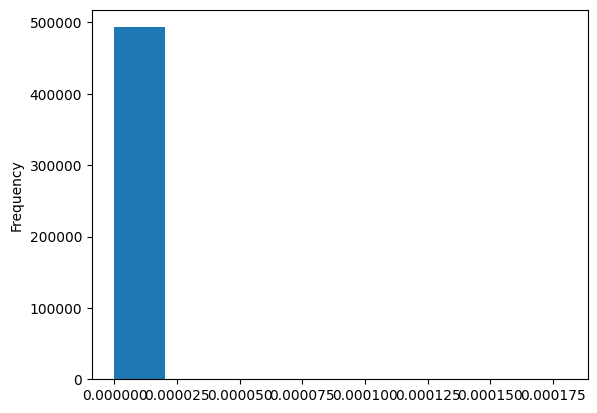

In [23]:
gdf_sjoin_nr.dist_gl_hl.plot.hist(bins=np.arange(0, 0.0002, 0.00002))

(0.0, 3000.0)

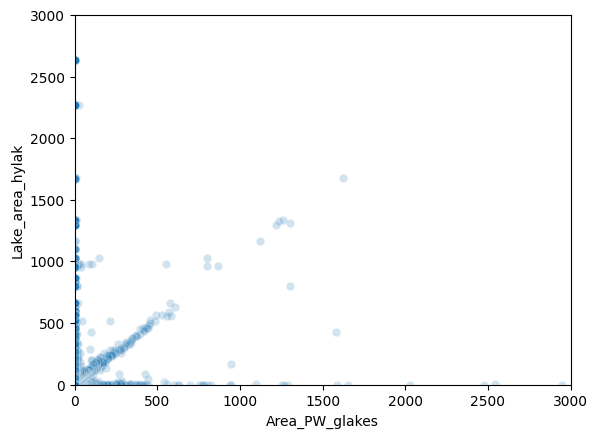

In [32]:
sns.scatterplot(gdf_sjoin_nr, x="Area_PW_glakes", y="Lake_area_hylak", alpha=0.2)
plt.xlim([0, 3000])
plt.ylim([0, 3000])

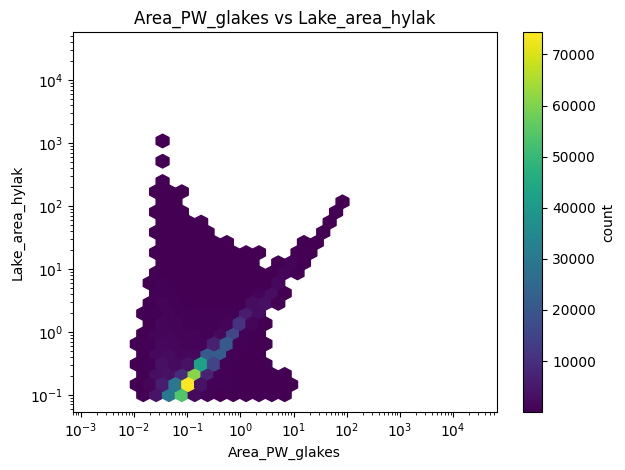

In [31]:
reg_hexplot(gdf_sjoin_nr, xvar="Area_PW_glakes", yvar="Lake_area_hylak", xscale="log", yscale="log")

### Spatial join via normal

In [72]:
# v1
gdf_sjoin = gdf_liu.sjoin(gdf_kuhn.drop(columns=["continent", "country"]), how="left")
gdf_sjoin

,Lake_id_glakes,Area_bound_glakes,Area_PW_glakes,Continent_glakes,Lat_glakes,Lon_glakes,GFed_flag_glakes,PFed_flag_glakes,Endo_flag_glakes,Rser_flag_glakes,...,Elevation_hylak,Slope_100_hylak,Wshd_area_hylak,Pour_long_hylak,Pour_lat_hylak,sen_slope,mann_kendall_trend,trend_significance,b2_mean,b2_stddev
0,3,82155.420436,79514.496612,North America,47.526368,-87.757371,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,30657.104741,28864.201812,North America,65.998658,-120.968462,0,1,0,0,...,145.0,-1.00,147665.4,-123.505546,65.138384,-0.000011,no sig. trend,0.95,0.0247,0.0032
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,217.0,0.53,9.6,-96.537239,50.745706,-0.000125,no sig. trend,0.27,0.0339,0.0023
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,216.0,0.36,0.4,-96.653766,50.389062,-0.000470,sig. decreasing,0.03,0.0535,0.0024
2,10,27480.339361,26652.927111,North America,52.825958,-97.738194,0,1,0,1,...,216.0,0.42,1.4,-98.190962,52.265912,-0.000288,no sig. trend,0.15,0.0276,0.0017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878279,3426379,0.030000,0.023372,North America,55.945998,-73.388277,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1878280,3426383,0.030000,0.021656,North America,47.218059,-79.545936,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1878281,3426386,0.030000,0.025493,North America,57.038875,-66.618051,0,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1878282,3426387,0.030000,0.021101,North America,63.005278,-147.988122,0,1,0,0,...,935.0,3.19,1.6,-147.988542,63.005504,-0.000562,sig. decreasing,0.04,0.0248,0.0021


Work around for joins/merge_left_one_one, which is hanging

In [73]:
left_key="Lake_id_glakes"
predicate="overlaps"
sort_by="Area_PW_glakes"
match_col="Lake_area_hylak"
float_fields=["b2_mean"]

In [74]:
grouped = gdf_sjoin.sort_values(sort_by).groupby(left_key, dropna=False)
join_counts = grouped[match_col].count()
reduced = grouped.last().reset_index()

In [75]:
if len(float_fields) > 0:
    reduced[float_fields] = grouped[float_fields].mean()
reduced["right_count"] = join_counts
gdf_sjoin = gpd.GeoDataFrame(reduced, geometry="geometry", crs=gdf_liu.crs)

In [76]:
# pretty print summary
non_nan = (~reduced[match_col].isna()).sum()
matched = np.nansum((reduced[match_col] > 0).to_numpy(dtype=float))
total = len(reduced)

print(
    f"Found {total:,} features; matches = {int(matched):,} / {int(non_nan):,}, length of left: {len(gdf_liu):,}"
)

Found 1,878,284 features; matches = 493,064 / 493,064, length of left: 1,878,284


In [77]:
# check for duplicate index
print(gdf_sjoin.index.duplicated().any())
print(gdf_sjoin["Hylak_id"].duplicated().any())

False
True


(0.0, 3000.0)

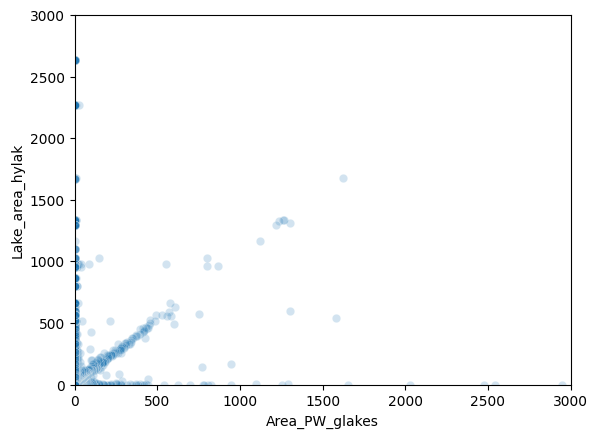

In [33]:
sns.scatterplot(gdf_sjoin, x="Area_PW_glakes", y="Lake_area_hylak", alpha=0.2)
plt.xlim([0, 3000])
plt.ylim([0, 3000])

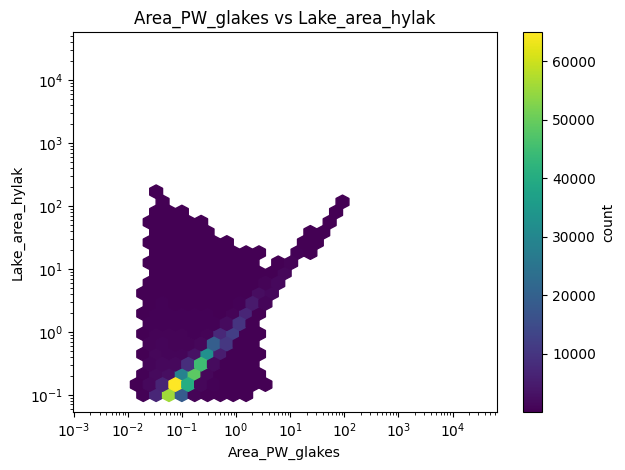

In [39]:
reg_hexplot(gdf_sjoin, xvar="Area_PW_glakes", yvar="Lake_area_hylak", xscale="log", yscale="log")

### Join using broken function

In [ ]:
# join without dups (not working)
gdf_sjoin = merge_left_one_one(
    gdf_liu,
    gdf_kuhn.drop(columns=["continent", "country"]),
    left_key="Lake_id_glakes",
    predicate="overlaps",
    sort_by="Area_PW_glakes",
    match_col="Lake_area_hylak",
    float_fields=["b2_mean"],
    rel_thresh=None,
)

## Postprocess and save

In [78]:
gdf_sjoin.rename(columns={"right_count": "hylak_count"}, inplace=True)
gdf_sjoin.drop(columns="index_right", inplace=True)

In [79]:
gdf_sjoin.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1878284 entries, 0 to 1878283
Data columns (total 70 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Lake_id_glakes      1878284 non-null  int64   
 1   Area_bound_glakes   1878284 non-null  float64 
 2   Area_PW_glakes      1877185 non-null  float64 
 3   Continent_glakes    1878284 non-null  object  
 4   Lat_glakes          1878284 non-null  float64 
 5   Lon_glakes          1878284 non-null  float64 
 6   GFed_flag_glakes    1878284 non-null  int64   
 7   PFed_flag_glakes    1878284 non-null  int64   
 8   Endo_flag_glakes    1878284 non-null  int64   
 9   Rser_flag_glakes    1878284 non-null  int64   
 10  Shape_Leng_glakes   1878284 non-null  float64 
 11  Shape_Area_glakes   1878284 non-null  float64 
 12  areaP1              542298 non-null   float64 
 13  areaP2              542944 non-null   float64 
 14  areaP3              542944 non-null   floa

In [80]:
gdf_sjoin.hylak_count.max()

np.float64(51.0)

In [ ]:
gdf_sjoin.to_file(greennessx2_albers_pth)

Join to GLOBATHY (based on hylak_id)

In [ ]:
# Load, if already computed
gdf_sjoin = gpd.read_file(greennessx2_albers_pth)

In [53]:
gdf_sjoin.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1878284 entries, 0 to 1878283
Data columns (total 64 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Lake_id_glakes      1878284 non-null  int64   
 1   Area_bound_glakes   1878284 non-null  float64 
 2   Area_PW_glakes      1877185 non-null  float64 
 3   Continent_glakes    1878284 non-null  object  
 4   Lat_glakes          1878284 non-null  float64 
 5   Lon_glakes          1878284 non-null  float64 
 6   GFed_flag_glakes    1878284 non-null  int64   
 7   PFed_flag_glakes    1878284 non-null  int64   
 8   Endo_flag_glakes    1878284 non-null  int64   
 9   Rser_flag_glakes    1878284 non-null  int64   
 10  Shape_Leng_glakes   1878284 non-null  float64 
 11  Shape_Area_glakes   1878284 non-null  float64 
 12  areaP1              542298 non-null   float64 
 13  areaP2              542944 non-null   float64 
 14  areaP3              542944 non-null   floa

In [82]:
# Globathy
df_globathy = loadGlobathy()

In [83]:
gdf_sjoin = gdf_sjoin.merge(df_globathy, on="Hylak_id", how="left", validate="many_to_one")

In [84]:
gdf_sjoin.info(show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1878284 entries, 0 to 1878283
Data columns (total 72 columns):
 #   Column              Non-Null Count    Dtype   
---  ------              --------------    -----   
 0   Lake_id_glakes      1878284 non-null  int64   
 1   Area_bound_glakes   1878284 non-null  float64 
 2   Area_PW_glakes      1877185 non-null  float64 
 3   Continent_glakes    1878284 non-null  object  
 4   Lat_glakes          1878284 non-null  float64 
 5   Lon_glakes          1878284 non-null  float64 
 6   GFed_flag_glakes    1878284 non-null  int64   
 7   PFed_flag_glakes    1878284 non-null  int64   
 8   Endo_flag_glakes    1878284 non-null  int64   
 9   Rser_flag_glakes    1878284 non-null  int64   
 10  Shape_Leng_glakes   1878284 non-null  float64 
 11  Shape_Area_glakes   1878284 non-null  float64 
 12  areaP1              542298 non-null   float64 
 13  areaP2              542944 non-null   float64 
 14  areaP3              542944 non-null   floa

In [85]:
# Add derived parameters
# dynamic ratio, Casa-Ruiz 2021, Håkanson 1982. Low= bowl, high=dish
gdf_sjoin["dyn_ratio_glak_hylak"] = np.sqrt(gdf_sjoin.Area_PW_glakes) / gdf_sjoin.Depth_avg_hylak
# depth ratio, Seekell et al 2021; Caell & Seekell 2023, 1/3 = conic
# low= bowl (large Littoral), close to 1=dish (small Littoral, unless shallow)
gdf_sjoin["depth_ratio_globath"] = gdf_sjoin.Depth_avg_hylak / gdf_sjoin.Dmax_use_m
# DR is supposedly uniformly distributed... not based on my inputs
# Just need compensation depth to calculate LZ area

In [ ]:
# Add more derived parameters, if needed
# gdf_sjoin["LEV_p13in"] = (
#     gdf_sjoin["LEV_p13ain"] / gdf_sjoin["area_1984_"] * 100
# )  # "Another type of relative increase, normalized to initial lake area
# gdf_sjoin.loc[gdf_sjoin["area_1984_"] == 0, "LEV_p13in"] = np.nan # avoid divide by zero

<Axes: ylabel='Frequency'>

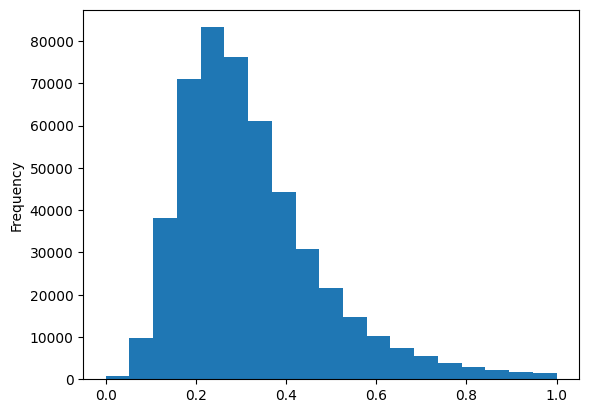

In [86]:
# gdf_sjoin["dyn_ratio"].plot.hist(bins=[0.001, 0.01, 0.1, 1, 10])
gdf_sjoin["depth_ratio_globath"].plot.hist(bins=np.linspace(0, 1, 20))

In [ ]:
# Update greennessx2 with GLOBATHY
gdf_sjoin.to_file(
    greennessx2_albers_pth
)

/Users/ekyzivat/mambaforge/envs/landcover/lib/python3.11/site-packages/pyogrio/raw.py:723: RuntimeWarning: Spatial index (perhaps created with GDAL 3.6.0) of table greennessx2 is corrupted. Disabling its use. This file should be recreated or its spatial index recreated
  ogr_write(


In [7]:
# Save to albers projection, if desired
gdf_sjoin.to_crs("ESRI:102001").to_file(greennessx2_albers_pth)